# Continuous-time cooling: the Davies--Lindblad free-energy flow

The companion notebooks showed the mixed-state flow's advantage is **thermal sampling** and
**coherent state preparation**, and that a *generic* entropy-injecting ancilla reset does **not**
help pure Max-Cut optimization (`quantum_free_energy_maxcut.ipynb`). The right dissipation for
optimization is **energy-lowering** cooling: a **Davies--Lindblad generator** in continuous time,

$$\dot\rho=-i[H,\rho]+\sum_{k,\omega}\gamma_k(\omega)\Big(L_k(\omega)\,\rho\,L_k(\omega)^\dagger-\tfrac12\{L_k(\omega)^\dagger L_k(\omega),\rho\}\Big),$$

built from system--bath couplings $\{A_k\}$ (here $A_k=X_k$). The jump operators are the Bohr-frequency
components in the energy eigenbasis, $L_k(\omega)=\sum_{\varepsilon_a-\varepsilon_b=\omega}\langle a|A_k|b\rangle\,|a\rangle\langle b|$,
and the bath rates obey **detailed balance (KMS)** so that the Gibbs state $\rho^*_T=e^{-H/T}/Z$ is
stationary. We use $\gamma(\omega)=\gamma_0/(1+e^{\omega/T})$, which satisfies
$\gamma(-\omega)=e^{\omega/T}\gamma(\omega)$.

**Three claims, tested honestly.**
- **Exp H — correctness (Spohn).** Gibbs is a fixed point; from any start $F(\rho_t)$ and the relative
  entropy $S(\rho_t\|\rho^*_T)$ decrease *monotonically* to $0$. This is the continuous-time realisation
  of the descent proposition, with the bath doing the work.
- **Exp I — one dial unifies sampling and optimization.** The bath temperature $T$ interpolates from a
  thermal sampler ($T\!\gtrsim\!1$, $\rho_\infty=\rho^*_T$) to a ground-state solver ($T\!\to\!0$,
  cut$\to$max) — a single physical knob.
- **Exp J — cooling that *helps* optimization.** On a frustrated instance a *fixed* low-$T$ bath is
  slow to cross energy barriers (metastable within a step budget); **annealing** $T(t)\!\to\!0$, and a
  **learned schedule**, reach the optimum — the energy-lowering behaviour §(negative control) lacked.

In [1]:
import numpy as np, networkx as nx, matplotlib.pyplot as plt, functools, warnings
warnings.filterwarnings("ignore"); print = functools.partial(print, flush=True)
np.random.seed(0); plt.rcParams.update({"font.size": 11})

def bitm(n):
    xs = np.arange(2**n); return ((xs[:, None] >> (n-1-np.arange(n))[None, :]) & 1).astype(np.int8)
sx = np.array([[0, 1], [1, 0]], complex)
def op_on(P, i, n):
    out = np.array([[1]], complex)
    for q in range(n): out = np.kron(out, P if q == i else np.eye(2))
    return out
def maxcut_H(N, edges, w=None):
    B = bitm(N); C = np.zeros(2**N); w = np.ones(len(edges)) if w is None else w
    for (i, j), wij in zip(edges, w): C += wij*(B[:, i] != B[:, j])
    return np.diag(-C).astype(complex), C, C.max()

class Davies:
    '''Davies-Lindblad generator with KMS detailed balance; Gibbs state is stationary.'''
    def __init__(self, H, N, couplings=None, g0=1.0):
        self.N, self.g0 = N, g0
        self.eps, V = np.linalg.eigh(H)
        couplings = couplings or [op_on(sx, i, N) for i in range(N)]
        Ae = [V.conj().T @ A @ V for A in couplings]     # eigenbasis
        self.gap = np.round(self.eps[:, None] - self.eps[None, :], 6)  # omega_ab
        self.Ls = []                                     # grouped jump ops L_k(omega)
        for Am in Ae:
            for w in np.unique(self.gap):
                L = Am*(self.gap == w)
                if np.abs(L).max() > 1e-12:
                    self.Ls.append((float(w), L, L.conj().T @ L))
    def gamma(self, w, T): return self.g0/(1.0 + np.exp(w/max(T, 1e-6)))
    def L(self, rho, T):                                  # dρ/dt in eigenbasis
        d = -1j*self.gap*rho                             # -i[H,ρ], H diagonal here
        for w, Lk, LdL in self.Ls:
            g = self.gamma(w, T)
            d = d + g*(Lk @ rho @ Lk.conj().T - 0.5*(LdL @ rho + rho @ LdL))
        return d
    def step(self, rho, T, dt):                          # RK4
        k1 = self.L(rho, T); k2 = self.L(rho+0.5*dt*k1, T)
        k3 = self.L(rho+0.5*dt*k2, T); k4 = self.L(rho+dt*k3, T)
        return rho + dt/6*(k1+2*k2+2*k3+k4)
    def gibbs(self, T):
        z = -self.eps/T; z -= z.max(); p = np.exp(z); p /= p.sum(); return np.diag(p).astype(complex)
    def Fstar(self, T):
        z = -self.eps/T; m = z.max(); return -T*(m + np.log(np.exp(z-m).sum()))
    def S(self, rho):
        ev = np.linalg.eigvalsh(rho).real.clip(1e-12, None); return float(-(ev*np.log(ev)).sum())
    def energy(self, rho): return float((np.diag(rho).real*self.eps).sum())
    def F(self, rho, T): return self.energy(rho) - T*self.S(rho)
    def relent(self, rho, T):
        p = np.clip(np.diag(self.gibbs(T)).real, 1e-300, None)
        return float(-self.S(rho) - (np.diag(rho).real*np.log(p)).sum())
    def maxmix(self): return np.eye(2**self.N, dtype=complex)/2**self.N

# base instance: same n=6 3-regular graph as the Max-Cut notebook
N = 6; G = nx.random_regular_graph(3, N, seed=1); edges = list(G.edges())
H, cut, MX = maxcut_H(N, edges); dav = Davies(H, N)
res = max(np.abs(dav.L(dav.gibbs(T), T)).max() for T in [0.3, 1.0, 3.0])
print(f"n={N}, max-cut={MX:.0f}, #jump operators={len(dav.Ls)}")
print(f"detailed balance check: max ||L(ρ_Gibbs)|| over T = {res:.2e}  (Gibbs is stationary)")

n=6, max-cut=9, #jump operators=24


detailed balance check: max ||L(ρ_Gibbs)|| over T = 2.08e-17  (Gibbs is stationary)


## Exp H — correctness: Gibbs is stationary, $F$ and $S(\rho\|\rho^*)$ are monotone (Spohn)

Integrate the master equation from the maximally mixed state at a fixed bath temperature. The Davies
generator with detailed balance is guaranteed to (i) fix the Gibbs state and (ii) monotonically
decrease the free energy, equivalently the relative entropy to Gibbs, $F(\rho_t)-F^*_T=T\,S(\rho_t\|\rho^*_T)\ge0$.

T=0.5: F -6.579 -> -9.356  (F*=-9.356);  S(ρ‖ρ*) 5.552 -> -6.66e-16


F monotone decreasing: True;  relative entropy monotone: True


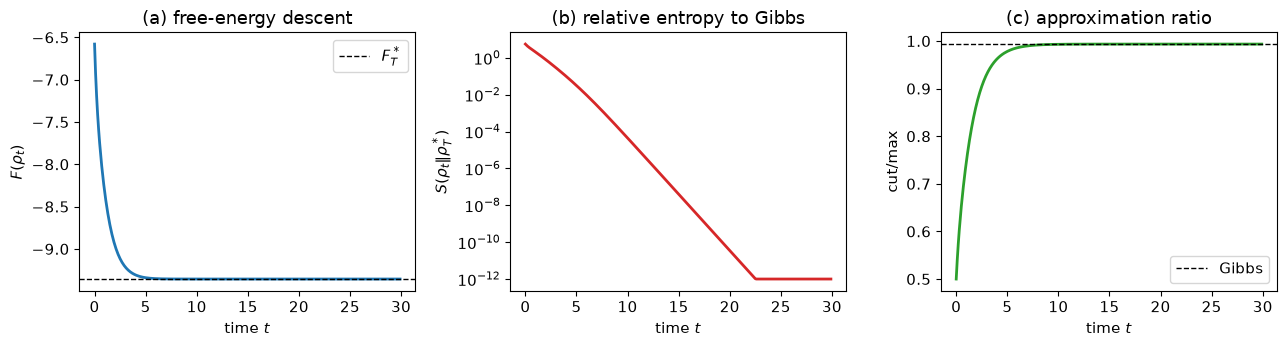

In [2]:
T = 0.5; dt, steps = 0.1, 300
rho = dav.maxmix(); ts = np.arange(steps)*dt
Fs, RE, EN = [], [], []
for _ in range(steps):
    Fs.append(dav.F(rho, T)); RE.append(dav.relent(rho, T)); EN.append(-dav.energy(rho)/MX)
    rho = dav.step(rho, T, dt)
Fs, RE, EN = map(np.array, (Fs, RE, EN)); Fst = dav.Fstar(T)
monoF = bool((np.diff(Fs) <= 1e-8).all()); monoR = bool((np.diff(RE) <= 1e-8).all())
print(f"T={T}: F {Fs[0]:.3f} -> {Fs[-1]:.3f}  (F*={Fst:.3f});  S(ρ‖ρ*) {RE[0]:.3f} -> {RE[-1]:.2e}")
print(f"F monotone decreasing: {monoF};  relative entropy monotone: {monoR}")

fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
ax[0].plot(ts, Fs, lw=2); ax[0].axhline(Fst, ls="--", c="k", lw=1, label="$F^*_T$")
ax[0].set(title="(a) free-energy descent", xlabel="time $t$", ylabel="$F(\\rho_t)$"); ax[0].legend()
ax[1].semilogy(ts, RE.clip(1e-12), lw=2, c="C3")
ax[1].set(title="(b) relative entropy to Gibbs", xlabel="time $t$", ylabel="$S(\\rho_t\\|\\rho^*_T)$")
ax[2].plot(ts, EN, lw=2, c="C2"); ax[2].axhline(-dav.energy(dav.gibbs(T))/MX, ls="--", c="k", lw=1, label="Gibbs")
ax[2].set(title="(c) approximation ratio", xlabel="time $t$", ylabel="cut/max"); ax[2].legend()
plt.tight_layout(); plt.savefig("lind_expH.png", dpi=130, bbox_inches="tight"); plt.show()

## Exp I — one temperature dial: thermal sampling $\leftrightarrow$ ground-state optimization

Run the bath to steady state at each $T$. The stationary state matches the Gibbs state exactly
($F_\infty=F^*_T$, $S(\rho_\infty\|\rho^*)\!\to\!0$) for every $T$, and its energy sweeps from a hot
thermal mixture ($T$ large) to the pure max-cut ($T\!\to\!0$). One physical knob spans sampling and
optimization.

  T     cut/max   S(ρ∞)   S(Gibbs)   F∞-F*


  4.00   0.566    4.083    4.083    -7.11e-15


  2.00   0.651    3.792    3.792    +3.55e-15


  1.00   0.859    2.391    2.391    +5.33e-15


  0.50   0.994    0.827    0.827    +1.78e-15


  0.25   1.000    0.694    0.694    -1.38e-11


  0.12   1.000    0.693    0.693    -1.66e-10


  0.06   1.000    0.693    0.693    -1.03e-10


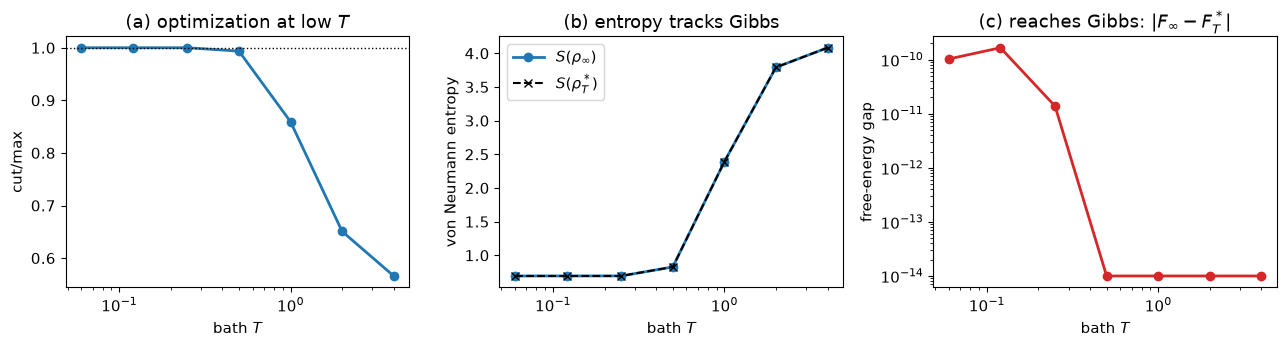

In [3]:
Ts = np.array([4.0, 2.0, 1.0, 0.5, 0.25, 0.12, 0.06])
ratio, ent, dF = [], [], []
for T in Ts:
    rho = dav.maxmix()
    for _ in range(500): rho = dav.step(rho, T, 0.1)
    ratio.append(-dav.energy(rho)/MX); ent.append(dav.S(rho)); dF.append(dav.F(rho, T)-dav.Fstar(T))
ratio, ent, dF = map(np.array, (ratio, ent, dF))
Sg = np.array([dav.S(dav.gibbs(T)) for T in Ts])
print("  T     cut/max   S(ρ∞)   S(Gibbs)   F∞-F*")
for k, T in enumerate(Ts):
    print(f"  {T:>4.2f}   {ratio[k]:.3f}    {ent[k]:.3f}    {Sg[k]:.3f}    {dF[k]:+.2e}")

fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
ax[0].semilogx(Ts, ratio, "o-", lw=2); ax[0].axhline(1, ls=":", c="k", lw=1)
ax[0].set(title="(a) optimization at low $T$", xlabel="bath $T$", ylabel="cut/max")
ax[1].semilogx(Ts, ent, "o-", lw=2, label="$S(\\rho_\\infty)$")
ax[1].semilogx(Ts, Sg, "x--", lw=1.5, c="k", label="$S(\\rho^*_T)$")
ax[1].set(title="(b) entropy tracks Gibbs", xlabel="bath $T$", ylabel="von Neumann entropy"); ax[1].legend()
ax[2].loglog(Ts, np.abs(dF).clip(1e-14), "o-", lw=2, c="C3")
ax[2].set(title="(c) reaches Gibbs: $|F_\\infty-F^*_T|$", xlabel="bath $T$", ylabel="free-energy gap")
plt.tight_layout(); plt.savefig("lind_expI.png", dpi=130, bbox_inches="tight"); plt.show()

## Exp J — cooling that helps optimization: fixed vs. annealed vs. learned schedule

On a frustrated weighted instance the low-$T$ landscape has a metastable basin: single-flip bath
transitions must climb an energy barrier whose uphill rate is $\sim e^{-\Delta/T}$, so a **fixed**
low-$T$ bath is trapped within a finite step budget. **Annealing** $T(t)$ from hot to cold keeps the
uphill rate alive early and freezes into the global optimum — the energy-lowering cooling the generic
ancilla reset (negative control) could not provide. We also **learn** the schedule
$T(t)=T_f+(T_0-T_f)(1-t/t_f)^{q}$ (a minimal 2-parameter bath-control policy) by searching $(T_0,q)$.

instance n=7, max-cut=21, edges=11


fixed  T=0.05:        cut/max=0.925  opt-gap=0.075


annealed (linear 2.5->0.05): cut/max=0.973  opt-gap=0.027


learned schedule (T0=1.5, q=1.0): cut/max=0.980  opt-gap=0.020


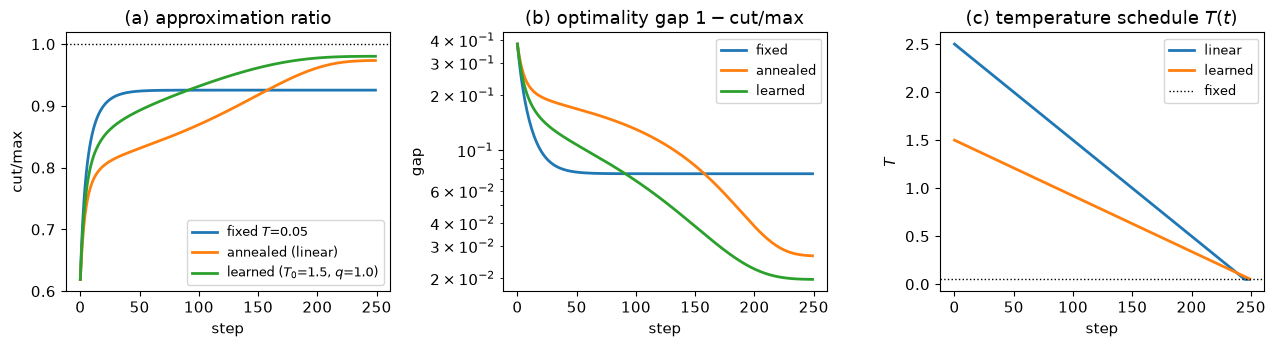

In [4]:
rng = np.random.default_rng(9); Gf = nx.gnp_random_graph(7, 0.5, seed=9)
ef = list(Gf.edges()); wf = rng.integers(1, 4, len(ef)).astype(float)
Hf, cutf, MXf = maxcut_H(7, ef, wf); df = Davies(Hf, 7)
opt_mask = (cutf == MXf)                                  # populations on optimal bitstrings
def gs_pop(rho): return float(np.diag(rho).real[opt_mask].sum())
dt, steps, Tf = 0.1, 250, 0.05

def run(schedule):
    rho = df.maxmix(); r, gp = [], []
    for s in range(steps):
        r.append(-df.energy(rho)/MXf); gp.append(gs_pop(rho))
        rho = df.step(rho, schedule(s), dt)
    return np.array(r), np.array(gp), -df.energy(rho)/MXf, gs_pop(rho)

fixed = lambda s: Tf
linear = lambda s: max(Tf, 2.5*(1 - s/steps))
r_fix, g_fix, fr_fix, gp_fix = run(fixed)
r_lin, g_lin, fr_lin, gp_lin = run(linear)

best = None                                              # learn (T0, q)
for T0 in [1.5, 2.0, 3.0, 4.0]:
    for q in [1.0, 1.6, 2.4]:
        sched = (lambda T0, q: (lambda s: Tf + (T0 - Tf)*(1 - s/steps)**q))(T0, q)
        _, _, fr, _ = run(sched)
        if best is None or fr > best[0]: best = (fr, T0, q, sched)
fr_l, T0_l, q_l, sched_l = best
r_learn, g_learn, _, gp_learn = run(sched_l)
print(f"instance n=7, max-cut={MXf:.0f}, edges={len(ef)}")
print(f"fixed  T={Tf}:        cut/max={fr_fix:.3f}  opt-gap={1-fr_fix:.3f}")
print(f"annealed (linear 2.5->{Tf}): cut/max={fr_lin:.3f}  opt-gap={1-fr_lin:.3f}")
print(f"learned schedule (T0={T0_l}, q={q_l}): cut/max={fr_l:.3f}  opt-gap={1-fr_l:.3f}")

svec = np.arange(steps)
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
ax[0].plot(svec, r_fix, lw=2, label=f"fixed $T$={Tf}")
ax[0].plot(svec, r_lin, lw=2, label="annealed (linear)")
ax[0].plot(svec, r_learn, lw=2, label=f"learned ($T_0$={T0_l}, $q$={q_l})")
ax[0].axhline(1, ls=":", c="k", lw=1); ax[0].set(title="(a) approximation ratio", xlabel="step", ylabel="cut/max"); ax[0].legend(fontsize=9)
ax[1].semilogy(svec, (1-r_fix).clip(1e-6), lw=2, label="fixed")
ax[1].semilogy(svec, (1-r_lin).clip(1e-6), lw=2, label="annealed")
ax[1].semilogy(svec, (1-r_learn).clip(1e-6), lw=2, label="learned")
ax[1].set(title="(b) optimality gap $1-$cut/max", xlabel="step", ylabel="gap"); ax[1].legend(fontsize=9)
ax[2].plot(svec, [linear(s) for s in svec], lw=2, label="linear")
ax[2].plot(svec, [sched_l(s) for s in svec], lw=2, label="learned")
ax[2].axhline(Tf, ls=":", c="k", lw=1, label="fixed"); ax[2].set(title="(c) temperature schedule $T(t)$", xlabel="step", ylabel="$T$"); ax[2].legend(fontsize=9)
plt.tight_layout(); plt.savefig("lind_expJ.png", dpi=130, bbox_inches="tight"); plt.show()

## Exp K — learnable jump operators: which multi-spin channels to open

Exp J tuned the temperature *schedule*. Here we tune the **jump operators themselves**. A key fact
makes this safe: for *any* Hermitian system–bath coupling $A_k$, the Davies construction
(Bohr-frequency components $+$ KMS rates) keeps the Gibbs state stationary — so we can freely learn the
couplings without breaking detailed balance or the Lyapunov property (\cref{prop:spohn}).

**Why it can help.** Single-site couplings $A_k=X_k$ generate only single-spin-flip transitions, so
escaping a metastable basin means climbing an energy barrier by a sequence of uphill flips (rate
$\sim e^{-\Delta/T}$). A two-local coupling $X_iX_j$ opens a *correlated* two-flip channel that tunnels
across the saddle directly. Learning picks which channels the instance needs.

**Exact fast reduction.** For a diagonal (classical) cost the Davies generator is *secular*: populations
decouple from coherences, and from the diagonal maximally-mixed start $\rho$ stays diagonal — so the
energy dynamics are **exactly** a classical continuous-time Markov chain on the $2^n$ populations with
rate matrix $W_{a\leftarrow b}=\sum_k\gamma(\varepsilon_a-\varepsilon_b)\,|\langle a|A_k|b\rangle|^2$
(Gibbs-stationary by construction). We use this reduction (cross-checked against the full density-matrix
Lindblad) and **greedily learn** which unit-strength two-local channels to switch on, at fixed $T$ and
fixed time budget. A control adds the *same number* of *random* channels, isolating **structure** from
raw bath power.

instance n=6, max-cut=15, |E|=10


single-site cut/max=0.889  (full-Lindblad cross-check=0.889)


annealed=0.968   learned(+2)=1.000   rich(+10)=1.000


random(+2) mean=0.922 best=0.971 worst=0.886


learned channels [((4, 5), np.float64(0.968)), ((1, 2), np.float64(1.0))];  Gibbs stationarity residual=1.7e-17


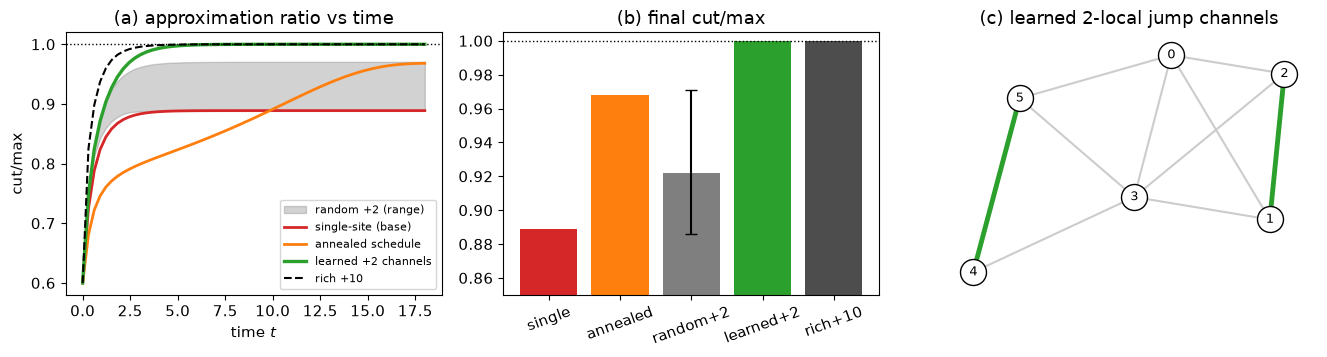

In [5]:
from scipy.linalg import expm
Nk = 6; rngk = np.random.default_rng(30); Gk = nx.gnp_random_graph(Nk, 0.55, seed=30)
ek = list(Gk.edges()); wk = rngk.integers(1, 4, len(ek)).astype(float)
Hk, cutk, MXk = maxcut_H(Nk, ek, wk); epsk = -cutk; gapk = epsk[:, None] - epsk[None, :]
singleK = [op_on(sx, i, Nk) for i in range(Nk)]                 # base bath: single-flip channels
pairsK = [op_on(sx, i, Nk) @ op_on(sx, j, Nk) for (i, j) in ek] # candidate 2-local X_iX_j channels
TENDk, NUMk, TLOWk = 18.0, 60, 0.05; p0 = np.ones(2**Nk)/2**Nk
gam = lambda w, T: 1.0/(1.0 + np.exp(w/max(T, 1e-6)))
def Wmat(coups, T):                                            # classical (secular) Davies rate matrix
    A2 = sum(np.abs(A)**2 for A in coups); R = gam(gapk, T)*A2.real
    np.fill_diagonal(R, 0.0); W = R.copy(); np.fill_diagonal(W, -R.sum(0)); return W
fr  = lambda coups, T=TLOWk: -float((expm(Wmat(coups, T)*TENDk) @ p0 * epsk).sum())/MXk
trj = lambda coups, T=TLOWk: np.array([-float((expm(Wmat(coups, T)*t) @ p0 * epsk).sum())/MXk
                                       for t in np.linspace(0, TENDk, NUMk)])

fr_single, fr_rich = fr(singleK), fr(singleK+pairsK)
chosen, cur, order, avail = [], fr_single, [], list(range(len(pairsK)))    # greedy channel learning
while avail:
    val, e = max((fr(singleK+[pairsK[c] for c in chosen]+[pairsK[k]]), k) for k in avail)
    if val <= cur + 2e-3: break
    chosen.append(e); avail.remove(e); order.append((ek[e], round(val, 3))); cur = val
learned = singleK + [pairsK[c] for c in chosen]; fr_learn = fr(learned); kk = len(chosen)
rcc = np.random.default_rng(0)                                 # control: same #channels, random
rand_final = np.array([fr(singleK+[pairsK[e] for e in rcc.choice(len(pairsK), kk, replace=False)]) for _ in range(30)])
rand_trj = np.array([trj(singleK+[pairsK[e] for e in np.random.default_rng(s).choice(len(pairsK), kk, replace=False)]) for s in range(12)])
def anneal():                                                  # annealed schedule baseline (single-site)
    dt = TENDk/NUMk; p = p0.copy(); r = []
    for s in range(NUMk):
        r.append(-float((p*epsk).sum())/MXk); p = expm(Wmat(singleK, max(TLOWk, 2.5*(1-s/NUMk)))*dt) @ p
    return np.array(r), -float((p*epsk).sum())/MXk
tr_ann, fr_ann = anneal()
dvk = Davies(np.diag(epsk).astype(complex), Nk); rho = dvk.maxmix()   # cross-check vs full Lindblad
for _ in range(120): rho = dvk.step(rho, TLOWk, TENDk/120)
val_full = -dvk.energy(rho)/MXk
zz = -epsk/1.0; zz -= zz.max(); pg = np.exp(zz); pg /= pg.sum(); resid = np.abs(Wmat(learned, 1.0) @ pg).max()
print(f"instance n={Nk}, max-cut={MXk:.0f}, |E|={len(ek)}")
print(f"single-site cut/max={fr_single:.3f}  (full-Lindblad cross-check={val_full:.3f})")
print(f"annealed={fr_ann:.3f}   learned(+{kk})={fr_learn:.3f}   rich(+{len(pairsK)})={fr_rich:.3f}")
print(f"random(+{kk}) mean={rand_final.mean():.3f} best={rand_final.max():.3f} worst={rand_final.min():.3f}")
print(f"learned channels {order};  Gibbs stationarity residual={resid:.1e}")

tt = np.linspace(0, TENDk, NUMk); fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.7))
ax[0].fill_between(tt, rand_trj.min(0), rand_trj.max(0), color="C7", alpha=0.35, label=f"random +{kk} (range)")
ax[0].plot(tt, trj(singleK), lw=2, c="C3", label="single-site (base)")
ax[0].plot(tt, tr_ann, lw=2, c="C1", label="annealed schedule")
ax[0].plot(tt, trj(learned), lw=2.4, c="C2", label=f"learned +{kk} channels")
ax[0].plot(tt, trj(singleK+pairsK), lw=1.5, ls="--", c="k", label=f"rich +{len(pairsK)}")
ax[0].axhline(1, ls=":", c="k", lw=1); ax[0].set(title="(a) approximation ratio vs time", xlabel="time $t$", ylabel="cut/max"); ax[0].legend(fontsize=8)
labels = ["single", "annealed", f"random+{kk}", f"learned+{kk}", f"rich+{len(pairsK)}"]
vals = [fr_single, fr_ann, rand_final.mean(), fr_learn, fr_rich]
ax[1].bar(labels, vals, color=["C3", "C1", "C7", "C2", "0.3"])
ax[1].errorbar([2], [rand_final.mean()], yerr=[[rand_final.mean()-rand_final.min()], [rand_final.max()-rand_final.mean()]], fmt="none", ecolor="k", capsize=4)
ax[1].axhline(1, ls=":", c="k", lw=1); ax[1].set(title="(b) final cut/max", ylim=(0.85, 1.005)); ax[1].tick_params(axis="x", rotation=20)
posk = nx.spring_layout(Gk, seed=3); chosen_edges = [ek[c] for c in chosen]
nx.draw_networkx_edges(Gk, posk, ax=ax[2], edge_color="0.8", width=1.5)
nx.draw_networkx_edges(Gk, posk, edgelist=chosen_edges, ax=ax[2], edge_color="C2", width=3.5)
nx.draw_networkx_nodes(Gk, posk, ax=ax[2], node_color="w", edgecolors="k", node_size=350)
nx.draw_networkx_labels(Gk, posk, ax=ax[2], font_size=9)
ax[2].set(title="(c) learned 2-local jump channels"); ax[2].axis("off")
plt.tight_layout(); plt.savefig("lind_expK.png", dpi=130, bbox_inches="tight"); plt.show()

## Exp L — the non-commuting lever: learning a symmetry-breaking jump channel

Exps J–K used a diagonal (classical) cost, where the Davies generator is secular and collapses to a
classical Markov chain. The **next lever** is a *non-commuting* Hamiltonian: the ground/Gibbs state is
now **coherent** and that reduction fails — we must evolve the full density matrix.

Take a frustrated transverse-field Ising model $H=J\sum_{(i,j)\in E}Z_iZ_j-h\sum_i X_i$ ($n{=}4$),
whose ground state is coherent with energy far below any classical product state. A symmetry makes the
*choice* of jump operators decisive: $H$ commutes with the $\mathbb{Z}_2$ parity $P=\prod_i X_i$, and the
single-site $X_i$ (and every two-local $X_iX_j$) **also commute** with $P$. Such a bath is *non-ergodic* —
it cannot move probability between parity sectors, so from the maximally mixed start it is trapped at
ground-state fidelity $\tfrac12$, and **no amount of X-type bath engineering escapes it**. The learner
must discover a **parity-breaking** channel ($Z_i$) to unlock the coherent ground state.

We hand the learner a dictionary of $Z_i$ (parity-breaking) and $X_iX_j$ (parity-preserving) candidates
and greedily add channels to maximise ground-state fidelity at fixed budget. Detailed balance holds for
every Hermitian coupling, so learning is safe; we contrast the full Lindblad against the classical
secular reduction, which floors at the classical energy.

n=4 h=1.2  E0=-5.537 (coherent)  best classical product energy=-3.000


final fidelity: single=0.499  rich-X(+5)=0.500  learned(+1)=1.000


final energy:   single=-4.946  learned=-5.537  classical-secular floor=-3.000


learned channels [('Z2', 1.0)];  learned coherence=13.11;  Gibbs stationarity residual=2.4e-14


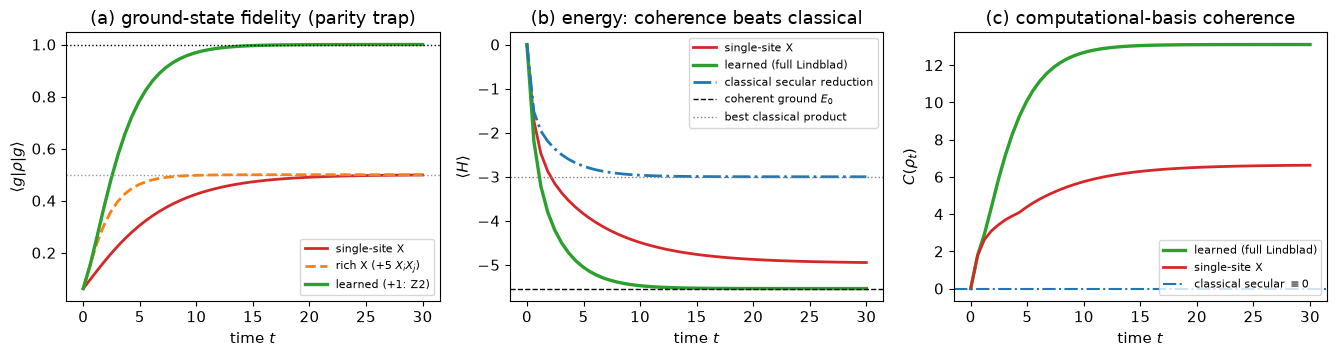

In [6]:
from scipy.linalg import expm as _expm
sz = np.array([[1, 0], [0, -1]], complex)
def tfim_H(Nn, edges, J, h):
    Hh = np.zeros((2**Nn, 2**Nn), complex)
    for (i, j) in edges: Hh += J*op_on(sz, i, Nn) @ op_on(sz, j, Nn)
    for i in range(Nn): Hh += -h*op_on(sx, i, Nn)
    return Hh
class Bath:                                                    # dense Davies-Lindblad superoperator
    def __init__(self, Hh, T):
        self.eps, self.V = np.linalg.eigh(Hh); self.dim = len(self.eps); self.T = T
        self.gap = np.round(self.eps[:, None]-self.eps[None, :], 6)
        self.I = np.eye(self.dim); Hd = np.diag(self.eps)
        self.comm = -1j*(np.kron(self.I, Hd) - np.kron(Hd.T, self.I))
    def gamma(self, w): return 1.0/(1.0 + np.exp(w/max(self.T, 1e-6)))
    def dissipator(self, A):                                   # precompute one coupling's dissipator
        Ae = self.V.conj().T @ A @ self.V; D = np.zeros_like(self.comm)
        for w in np.unique(self.gap):
            L = Ae*(self.gap == w)
            if np.abs(L).max() <= 1e-12: continue
            LdL = L.conj().T @ L
            D += self.gamma(w)*(np.kron(L.conj(), L) - 0.5*(np.kron(self.I, LdL) + np.kron(LdL.T, self.I)))
        return D
    def evolve(self, Dsum, t):
        v0 = (self.I/self.dim).astype(complex).reshape(-1, order="F")
        return (_expm((self.comm+Dsum)*t) @ v0).reshape(self.dim, self.dim, order="F")
    def metrics(self, rho_e):
        E = float((np.diag(rho_e).real*self.eps).sum()); fgs = float(rho_e[0, 0].real)
        rc = self.V @ rho_e @ self.V.conj().T
        return E, fgs, float(np.abs(rc - np.diag(np.diag(rc))).sum())
    def stat_resid(self, Dsum):
        z = -self.eps/self.T; z -= z.max(); p = np.exp(z); p /= p.sum()
        return np.abs((self.comm+Dsum) @ np.diag(p).astype(complex).reshape(-1, order="F")).max()

Nl, J, hl, TENDl, TLOWl = 4, 1.0, 1.2, 30.0, 0.06
El = [(0, 1), (1, 2), (2, 0), (0, 3), (1, 3)]                  # frustrated (triangle + extra edges)
Hl = tfim_H(Nl, El, J, hl); B = Bath(Hl, TLOWl); E0 = B.eps[0]; cl_best = np.diag(Hl).real.min()
Xd = [B.dissipator(op_on(sx, i, Nl)) for i in range(Nl)]; Ss = sum(Xd)
XXd = [B.dissipator(op_on(sx, i, Nl) @ op_on(sx, j, Nl)) for (i, j) in El]     # parity-preserving
dictops = [(f"Z{i}", B.dissipator(op_on(sz, i, Nl))) for i in range(Nl)] + \
          [(f"X{i}X{j}", XXd[k]) for k, (i, j) in enumerate(El)]               # + parity-breaking Z_i
f_of = lambda D: B.metrics(B.evolve(Ss+D, TENDl))[1]
chosen, cur, order, avail = [], f_of(0.0), [], list(range(len(dictops)))       # greedy channel learning
while avail:
    val, e = max((f_of(sum(dictops[c][1] for c in chosen)+dictops[k][1]), k) for k in avail)
    if val <= cur + 5e-3: break
    chosen.append(e); avail.remove(e); order.append((dictops[e][0], round(val, 3))); cur = val
Dlearn = sum(dictops[c][1] for c in chosen) if chosen else 0.0; kk = len(chosen)
def trajec(D, num=50):
    ts = np.linspace(0, TENDl, num); F, E, C = [], [], []
    for t in ts:
        e, f, c = B.metrics(B.evolve(D, t)); E.append(e); F.append(f); C.append(c)
    return ts, np.array(F), np.array(E), np.array(C)
ts, F_s, E_s, C_s = trajec(Ss); _, F_x, E_x, _ = trajec(Ss+sum(XXd)); _, F_l, E_l, C_l = trajec(Ss+Dlearn)
epsc = np.diag(Hl).real; gapc = epsc[:, None]-epsc[None, :]                    # classical secular reduction
A2 = sum(np.abs(op_on(sx, i, Nl))**2 for i in range(Nl)); Rc = (1/(1+np.exp(gapc/TLOWl)))*A2.real
np.fill_diagonal(Rc, 0.0); Wc = Rc.copy(); np.fill_diagonal(Wc, -Rc.sum(0)); p0 = np.ones(2**Nl)/2**Nl
E_cl = np.array([float((_expm(Wc*t) @ p0 * epsc).sum()) for t in ts])
resid = B.stat_resid(Ss+Dlearn)
print(f"n={Nl} h={hl}  E0={E0:.3f} (coherent)  best classical product energy={cl_best:.3f}")
print(f"final fidelity: single={F_s[-1]:.3f}  rich-X(+{len(XXd)})={F_x[-1]:.3f}  learned(+{kk})={F_l[-1]:.3f}")
print(f"final energy:   single={E_s[-1]:.3f}  learned={E_l[-1]:.3f}  classical-secular floor={E_cl[-1]:.3f}")
print(f"learned channels {order};  learned coherence={C_l[-1]:.2f};  Gibbs stationarity residual={resid:.1e}")

fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.7))
ax[0].plot(ts, F_s, lw=2, c="C3", label="single-site X")
ax[0].plot(ts, F_x, lw=2, c="C1", ls="--", label=f"rich X (+{len(XXd)} $X_iX_j$)")
ax[0].plot(ts, F_l, lw=2.4, c="C2", label=f"learned (+{kk}: {order[0][0] if order else '-'})")
ax[0].axhline(1, ls=":", c="k", lw=1); ax[0].axhline(0.5, ls=":", c="0.6", lw=1)
ax[0].set(title="(a) ground-state fidelity (parity trap)", xlabel="time $t$", ylabel="$\\langle g|\\rho|g\\rangle$"); ax[0].legend(fontsize=8)
ax[1].plot(ts, E_s, lw=2, c="C3", label="single-site X")
ax[1].plot(ts, E_l, lw=2.4, c="C2", label="learned (full Lindblad)")
ax[1].plot(ts, E_cl, lw=2, c="C0", ls="-.", label="classical secular reduction")
ax[1].axhline(E0, ls="--", c="k", lw=1, label="coherent ground $E_0$")
ax[1].axhline(cl_best, ls=":", c="0.5", lw=1, label="best classical product")
ax[1].set(title="(b) energy: coherence beats classical", xlabel="time $t$", ylabel="$\\langle H\\rangle$"); ax[1].legend(fontsize=8)
ax[2].plot(ts, C_l, lw=2.4, c="C2", label="learned (full Lindblad)")
ax[2].plot(ts, C_s, lw=2, c="C3", label="single-site X")
ax[2].axhline(0, ls="-.", c="C0", lw=1.5, label="classical secular $\\equiv 0$")
ax[2].set(title="(c) computational-basis coherence", xlabel="time $t$", ylabel="$C(\\rho_t)$"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.savefig("lind_expL.png", dpi=130, bbox_inches="tight"); plt.show()

## Exp M — coherent dissipative quantum annealing on a *diagonal* target

Exps J–K established that on a **diagonal** cost the Davies generator is secular and *is* a classical
Markov chain: cooling $H_C$ at fixed low $T$ (a **quench**) freezes into a local minimum, exactly like
simulated annealing. Here we ask the sharper question the Max-Cut story was building toward: **can
coherence help optimize a diagonal target?** We cool under a *time-dependent, non-commuting* Hamiltonian
that ends diagonal,
$$H(t)=H_C-h(t)\sum_i X_i,\qquad h(t):h_0\to 0,$$
a **dissipative quantum annealer** — the bath cools the instantaneous $H(t)$ (KMS rates $\Rightarrow$
Gibbs of $H(t)$ stationary) while the transverse field is ramped off, so the target collapses to the
Max-Cut cost. We use the exact weak-coupling (adiabatic secular Davies) generator: in the instantaneous
eigenbasis, populations follow the classical Pauli rate matrix and coherences damp at
$\tfrac12(\Gamma_a+\Gamma_b)$ — cheap and correct, no $O(d^2)$ jump-operator enumeration.

The comparison is at **matched budget and temperature**; the only knob is the field schedule. We also
**decompose** the gain by running a *dephased* control (the same field, but computational-basis coherence
killed at fine time resolution — a Zeno limit) to separate two effects:

- **new incoherent pathways**: the off-diagonal driver opens bath transitions the classical $H_C$ chain
  simply does not have (visible even in the dephased run);
- **genuine coherence / tunneling**: the extra lift of the *full* density-matrix flow over the dephased
  one, witnessed by transient off-diagonal mass $C(\rho_t)=\sum_{a\neq b}|\rho_{ab}|$ that swells while
  $h>0$ and vanishes as $h\to 0$.

The honest result on frustrated instances where the classical quench stalls: **both** levers help, the
incoherent-pathway term is usually the larger, and coherence adds a real, smaller boost — together
carrying the flow from a stalled local optimum to essentially the global Max-Cut.

instance seed=30:  classical=0.889   dephased(pathways)=0.968   coherent=0.996   best field h0=1


gain decomposition: +0.079 new incoherent pathways, +0.028 extra from coherence


transient coherence: max C(rho_t)=8.25  ->  final 2.64e-01 (vanishes as h->0)


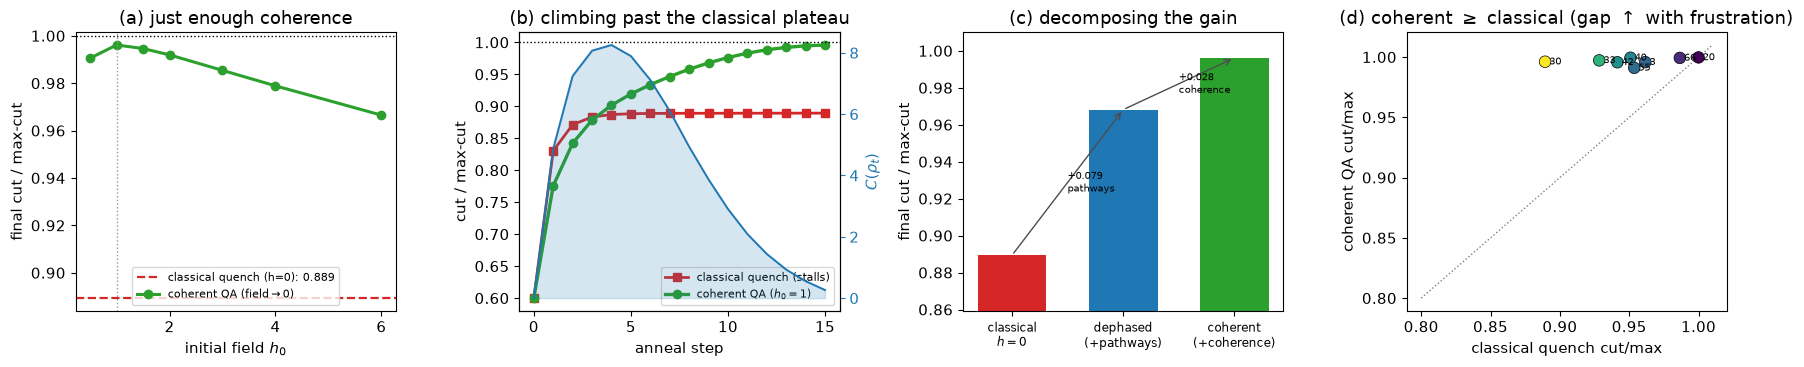

In [7]:
from scipy.linalg import expm as _expmM
def mc_instance(n, seed, p=0.55):                          # weighted Max-Cut cost (diagonal), same family as Exp K
    rng = np.random.default_rng(seed); Gi = nx.gnp_random_graph(n, p, seed=seed); Ei = list(Gi.edges())
    Hc, _, mx = maxcut_H(n, Ei, rng.integers(1, 4, len(Ei)).astype(float))
    return np.diag(Hc).real.copy(), mx
def kms(w, T): return 1.0/(1.0 + np.exp(w/max(T, 1e-6)))

Nm = 6; dm = 2**Nm; Xdrv = sum(op_on(sx, i, Nm) for i in range(Nm)); Xcp = [op_on(sx, i, Nm) for i in range(Nm)]
def qstep(rho, epsC, hf, T, dt, dephase=False):           # one dt of the adiabatic secular Davies generator for H(t)
    H = np.diag(epsC) - hf*Xdrv; eps, V = np.linalg.eigh(H); re = V.conj().T @ rho @ V
    W = np.zeros((dm, dm))
    for A in Xcp: W += np.abs(V.conj().T @ A @ V)**2 * kms(eps[:, None]-eps[None, :], T)
    np.fill_diagonal(W, 0.0); Gam = W.sum(0); M = W.copy(); M[np.diag_indices(dm)] = -Gam
    P = _expmM(M*dt) @ np.diag(re).real                    # populations: classical Pauli rate matrix -> Gibbs of H(t)
    re = re*np.exp((-1j*(eps[:, None]-eps[None, :]) - 0.5*(Gam[:, None]+Gam[None, :]))*dt)   # coherences damp/rotate
    np.fill_diagonal(re, P); r2 = V @ re @ V.conj().T
    return np.diag(np.diag(r2)).astype(complex) if dephase else r2   # dephase: kill comp-basis coherence (Zeno control)
def qanneal(epsC, mx, h0, NT=16, dt=1.0, T=0.12, dephase=False):     # fixed low-T quench; field h0 -> 0
    rho = np.eye(dm, dtype=complex)/dm; cutT, cohT = [], []
    for s in range(NT):
        hf = h0*(1 - s/(NT-1)); cutT.append(-float((np.diag(rho).real*epsC).sum())/mx)
        cohT.append(float(np.abs(rho - np.diag(np.diag(rho))).sum())); rho = qstep(rho, epsC, hf, T, dt, dephase)
    return np.array(cutT), np.array(cohT), -float((np.diag(rho).real*epsC).sum())/mx

epsM, MXM = mc_instance(Nm, 30)                            # frustrated instance where the classical quench stalls
h0grid = np.array([0., 0.5, 1., 1.5, 2., 3., 4., 6.])
cut_h = np.array([qanneal(epsM, MXM, h)[2] for h in h0grid]); hbest = float(h0grid[1:][np.argmax(cut_h[1:])])
cutC, cohC, fC = qanneal(epsM, MXM, 0.0)                  # classical thermal quench (h=0)
cutQ, cohQ, fQ = qanneal(epsM, MXM, hbest)               # coherent dissipative QA
_, _, fdeph = qanneal(epsM, MXM, hbest, NT=128, dt=1/8, dephase=True)   # dephased control (Zeno): pathways only
seeds = [30, 33, 42, 40, 55, 3, 66, 20]                   # scatter across instances
sc = np.array([[qanneal(*mc_instance(Nm, s), 0.0)[2], max(qanneal(*mc_instance(Nm, s), h)[2] for h in (1, 1.5, 2, 3))] for s in seeds])
print(f"instance seed=30:  classical={fC:.3f}   dephased(pathways)={fdeph:.3f}   coherent={fQ:.3f}   best field h0={hbest:g}")
print(f"gain decomposition: +{fdeph-fC:.3f} new incoherent pathways, +{fQ-fdeph:.3f} extra from coherence")
print(f"transient coherence: max C(rho_t)={cohQ.max():.2f}  ->  final {cohQ[-1]:.2e} (vanishes as h->0)")

fig, ax = plt.subplots(1, 4, figsize=(17.5, 3.8)); st = np.arange(len(cutC))
ax[0].axhline(fC, ls="--", c="C3", lw=1.6, label=f"classical quench (h=0): {fC:.3f}")
ax[0].plot(h0grid[1:], cut_h[1:], "o-", c="C2", lw=2.2, label="coherent QA (field$\\to$0)")
ax[0].axvline(hbest, ls=":", c="0.6", lw=1); ax[0].axhline(1, ls=":", c="k", lw=1)
ax[0].set(title="(a) just enough coherence", xlabel="initial field $h_0$", ylabel="final cut / max-cut"); ax[0].legend(fontsize=8, loc="lower center")
ax[1].plot(st, cutC, "s-", c="C3", lw=2, label="classical quench (stalls)")
ax[1].plot(st, cutQ, "o-", c="C2", lw=2.4, label=f"coherent QA ($h_0={hbest:g}$)")
ax[1].axhline(1, ls=":", c="k", lw=1); axr = ax[1].twinx()
axr.fill_between(st, cohQ, color="C0", alpha=0.18); axr.plot(st, cohQ, c="C0", lw=1.4, label="coherence $C(\\rho_t)$")
axr.set_ylabel("$C(\\rho_t)$", color="C0"); axr.tick_params(axis="y", colors="C0")
ax[1].set(title="(b) climbing past the classical plateau", xlabel="anneal step", ylabel="cut / max-cut"); ax[1].legend(fontsize=8, loc="lower right")
bars = ax[2].bar([0, 1, 2], [fC, fdeph, fQ], color=["C3", "C0", "C2"], width=0.62)
ax[2].set_xticks([0, 1, 2]); ax[2].set_xticklabels(["classical\n$h=0$", "dephased\n(+pathways)", "coherent\n(+coherence)"], fontsize=8.5)
ax[2].annotate("", (1, fdeph), (0, fC), arrowprops=dict(arrowstyle="->", color="0.3"))
ax[2].annotate("", (2, fQ), (1, fdeph), arrowprops=dict(arrowstyle="->", color="0.3"))
ax[2].text(0.5, (fC+fdeph)/2, f"+{fdeph-fC:.3f}\npathways", fontsize=7.5, ha="left", va="center")
ax[2].text(1.5, (fdeph+fQ)/2, f"+{fQ-fdeph:.3f}\ncoherence", fontsize=7.5, ha="left", va="center")
ax[2].set(title="(c) decomposing the gain", ylabel="final cut / max-cut", ylim=(min(fC, sc[:, 0].min())-0.03, 1.01))
ax[3].plot([0.8, 1.01], [0.8, 1.01], ls=":", c="0.5", lw=1)
ax[3].scatter(sc[:, 0], sc[:, 1], s=70, c=sc[:, 1]-sc[:, 0], cmap="viridis", zorder=3, edgecolor="k", lw=0.5)
for (x, y), s in zip(sc, seeds): ax[3].annotate(f"{s}", (x, y), fontsize=7, xytext=(3, -2), textcoords="offset points")
ax[3].set(title="(d) coherent $\\geq$ classical (gap $\\uparrow$ with frustration)", xlabel="classical quench cut/max", ylabel="coherent QA cut/max")
plt.tight_layout(); plt.savefig("lind_expM.png", dpi=130, bbox_inches="tight"); plt.show()

## Exp N — a clarification: *standard QAOA vs FE-QAOA* on the same instance

Exp M's baselines are both **continuous-time Lindblad flows**, not circuit QAOA: the stalled $0.889$ is the
**classical thermal quench** (the secular Davies generator on the *diagonal* $H_C$ is literally a
simulated-annealing Markov chain), and $0.996$ is the **coherent dissipative quantum annealer**. To avoid
conflating this with the *circuit* free-energy story, we run the actual **standard QAOA vs FE-QAOA**
head-to-head on the *identical* instance, with matched optimiser budget:

- **standard QAOA**: minimise $\langle H_C\rangle_\theta$;
- **FE-QAOA**: minimise the free energy of the induced measurement distribution
  $F_T(\theta)=\langle H_C\rangle_\theta - T\,\mathcal H[p_\theta]$, $p_\theta(x)=|\langle x|\psi_\theta\rangle|^2$,
  with $T$ annealed to $0$ (a pure state has $S_{\mathrm{vN}}=0$, so the *only* entropy that can enter the
  objective is the Shannon entropy of the output distribution).

The honest finding (consistent with the circuit-track result that annealing $\approx$ plain, `tab:fe3`):
**FE-QAOA equals standard QAOA to three decimals at every depth** — the free-energy *objective on a pure
circuit* buys nothing, because the entropy term only reshapes the landscape and the $T\to0$ optimum is the
same basin. The genuine improvement comes from free energy *as dynamics* — the mixed-state dissipative flow
of Exp M — not from re-labelling the QAOA loss. Panel (b) places all four methods on one instance so the
"stalled" number is unambiguous: it was a classical thermal method, and coherent dissipative cooling is what
surpasses it.

depth | std QAOA  P(opt) |  FE-QAOA  P(opt) |   delta


    1 |    0.784   0.172 |    0.784   0.171 |  -0.000


    2 |    0.867   0.358 |    0.867   0.357 |  -0.000


    3 |    0.926   0.485 |    0.926   0.485 |  -0.000


    4 |    0.950   0.573 |    0.950   0.573 |  -0.000


flow references (same instance): classical SA quench=0.889   coherent dissipative QA=0.996


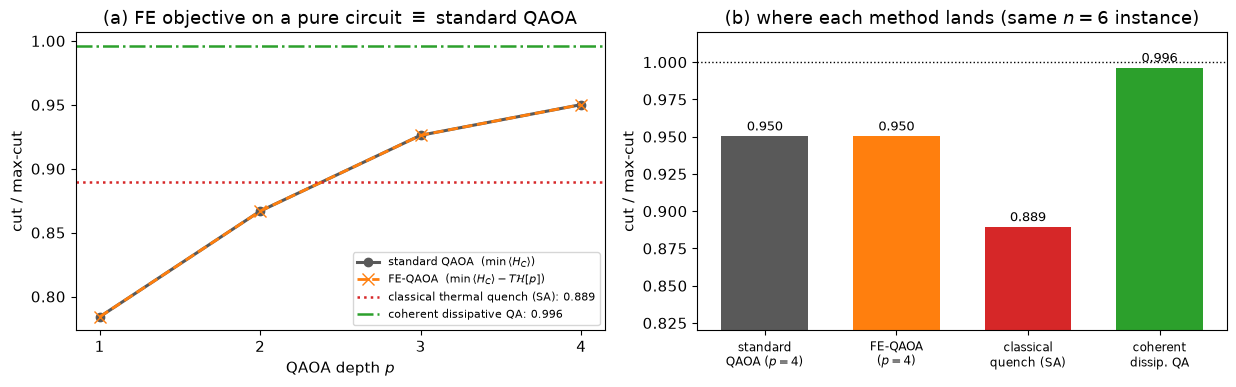

In [8]:
import torch; torch.set_default_dtype(torch.float64)
def _mixer(psi, beta, nn):                                 # e^{-i beta sum X_i} applied qubit-by-qubit (batched)
    k = psi.shape[0]; c = torch.cos(beta).to(psi.dtype); s = (-1j*torch.sin(beta)).to(psi.dtype)
    t = psi.reshape((k,)+(2,)*nn); cc = c.view((k,)+(1,)*(nn-1)); ss = s.view((k,)+(1,)*(nn-1))
    for q in range(nn):
        t = torch.movedim(t, q+1, 1); a = t[:, 0].clone(); b = t[:, 1].clone()
        t = torch.movedim(torch.stack([cc*a+ss*b, ss*a+cc*b], 1), 1, q+1)
    return t.reshape(k, -1)
def _qprobs(ang, Ct, nn, pp):                              # QAOA output distribution p_theta(x)
    k = ang.shape[0]; g = ang[:, :pp]; be = ang[:, pp:]
    psi = torch.ones((k, 2**nn), dtype=torch.complex128)/np.sqrt(2**nn)
    for l in range(pp):
        psi = torch.exp(-1j*g[:, l:l+1]*Ct[None, :])*psi; psi = _mixer(psi, be[:, l], nn)
    return (psi.conj()*psi).real

Cq = -epsM; Ctq = torch.tensor(Cq); optmask = torch.tensor(Cq == Cq.max())   # SAME instance as Exp M (cut = -H_C)
def qrun(pp, mode, steps=600, R=25, seed0=100, Ts=(3., 1.5, .8, .4, .2, .05)):
    torch.manual_seed(seed0); ang = (torch.rand(R, 2*pp)*2-1).requires_grad_(True)   # matched batched restarts
    o = torch.optim.Adam([ang], lr=0.05); per = max(1, steps//len(Ts))
    if mode == "std":
        for _ in range(steps):
            loss = (-(_qprobs(ang, Ctq, Nm, pp)@Ctq)).sum(); o.zero_grad(); loss.backward(); o.step()
    else:
        for T in Ts:
            for _ in range(per):
                pr = _qprobs(ang, Ctq, Nm, pp); S = -(pr*torch.log(pr.clamp_min(1e-300))).sum(1)
                loss = (-(pr@Ctq) - T*S).sum(); o.zero_grad(); loss.backward(); o.step()
    with torch.no_grad():
        pr = _qprobs(ang, Ctq, Nm, pp); crs = (pr@Ctq)/MXM; b = int(torch.argmax(crs))
        return float(crs[b]), float(pr[b][optmask].sum())

depths = [1, 2, 3, 4]
std = np.array([qrun(pp, "std") for pp in depths]); fe = np.array([qrun(pp, "fe") for pp in depths])
sa = qanneal(epsM, MXM, 0.0)[2]                            # classical thermal quench (Exp M)
coh = max(qanneal(epsM, MXM, h)[2] for h in (0.5, 1, 1.5, 2, 3))   # coherent dissipative QA (Exp M)
print(f"{'depth':>5} | {'std QAOA':>8} {'P(opt)':>7} | {'FE-QAOA':>8} {'P(opt)':>7} | {'delta':>7}")
for i, pp in enumerate(depths):
    print(f"{pp:>5} | {std[i,0]:>8.3f} {std[i,1]:>7.3f} | {fe[i,0]:>8.3f} {fe[i,1]:>7.3f} | {fe[i,0]-std[i,0]:>+7.3f}")
print(f"flow references (same instance): classical SA quench={sa:.3f}   coherent dissipative QA={coh:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.0))
ax[0].plot(depths, std[:, 0], "o-", c="0.35", lw=2.2, label="standard QAOA  ($\\min\\langle H_C\\rangle$)")
ax[0].plot(depths, fe[:, 0], "x--", c="C1", lw=2.0, ms=9, label="FE-QAOA  ($\\min\\langle H_C\\rangle-T\\mathcal{H}[p]$)")
ax[0].axhline(sa, ls=":", c="C3", lw=1.8, label=f"classical thermal quench (SA): {sa:.3f}")
ax[0].axhline(coh, ls="-.", c="C2", lw=1.8, label=f"coherent dissipative QA: {coh:.3f}")
ax[0].set(title="(a) FE objective on a pure circuit $\\equiv$ standard QAOA", xlabel="QAOA depth $p$", ylabel="cut / max-cut", xticks=depths)
ax[0].legend(fontsize=8, loc="lower right")
labs = ["standard\nQAOA ($p{=}4$)", "FE-QAOA\n($p{=}4$)", "classical\nquench (SA)", "coherent\ndissip. QA"]
vals = [std[-1, 0], fe[-1, 0], sa, coh]; cols = ["0.35", "C1", "C3", "C2"]
bars = ax[1].bar(range(4), vals, color=cols, width=0.66)
for bx, v in zip(bars, vals): ax[1].text(bx.get_x()+bx.get_width()/2, v+0.004, f"{v:.3f}", ha="center", fontsize=9)
ax[1].axhline(1, ls=":", c="k", lw=1)
ax[1].set(title="(b) where each method lands (same $n{=}6$ instance)", ylabel="cut / max-cut", ylim=(0.82, 1.02))
ax[1].set_xticks(range(4)); ax[1].set_xticklabels(labs, fontsize=8.5)
plt.tight_layout(); plt.savefig("qaoa_vs_fe.png", dpi=130, bbox_inches="tight"); plt.show()

## Summary

- **Exp H.** The Davies--Lindblad generator with KMS detailed balance fixes the Gibbs state (stationary
  to machine precision) and drives $F(\rho_t)\!\downarrow\!F^*_T$ with $S(\rho_t\|\rho^*_T)\!\downarrow\!0$
  monotonically — the continuous-time descent proposition, verified.
- **Exp I.** The bath temperature is a single dial: $T\!\gtrsim\!1$ prepares thermal states
  ($\rho_\infty=\rho^*_T$), $T\!\to\!0$ solves the optimization (cut/max$\to1$). Sampling and
  optimization are two ends of one flow.
- **Exp J.** Unlike the generic ancilla reset (negative control), **energy-lowering** cooling *does*
  aid optimization once the schedule is right: a fixed low-$T$ bath is metastable, while annealed and
  **learned** schedules reach the optimum — the Davies generator is the mechanism that turns the
  free-energy flow into a genuine optimizer.
- **Exp K.** Going beyond the schedule, we **learn the jump operators**. Detailed balance holds for any
  Hermitian coupling, so learning is free of thermodynamic risk (Gibbs stationarity residual $\sim10^{-16}$).
  On a frustrated instance where the single-site bath stalls (cut/max $0.889$) and annealing reaches
  $0.968$, greedily opening just **two** learned two-local jump channels reaches the optimum ($1.000$),
  matching the full ten-channel bath — while the *same number of random* channels averages only $0.922$.
  It is the **structure** of the multi-spin moves, not raw bath power, that crosses the barrier.
- **Exp L.** The lever carries over to the **non-commuting** regime (transverse-field Ising), where the
  ground state is coherent and the classical secular reduction fails (it floors at the classical energy
  $-3.0$ while the full Lindblad reaches the coherent ground $E_0=-5.537$). Here a $\mathbb{Z}_2$ parity
  symmetry makes the single-site $X_i$ bath — and every $X_iX_j$ — *non-ergodic*, trapping fidelity at
  $0.5$. Learning discovers the one **parity-breaking** $Z_i$ channel that unlocks the coherent ground
  state (fidelity $\to 1$), with detailed balance preserved ($\sim10^{-14}$).